<a href="https://colab.research.google.com/github/artemsorokin120504-star/-2026-103-/blob/main/Lab06_telecom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Упражнение 6

In [1]:
import os
if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-29 17:56:53--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-29 17:56:54--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.007s  

2026-05-29 17:56:54 (6.57 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
from thinkdsp import normalize, unbias, read_wave, PinkNoise, decorate, UncorrelatedGaussianNoise, Spectrum, Spectrogram, Wave, Noise, PI2, Dct
from scipy.stats import linregress
from scipy.fftpack import dct

import numpy as np
import matplotlib.pyplot as plt

Упражнение 6.1

Автор учебника утверждает, что функция **`analyze1`** имеет временную сложность $O(n^3)$, а функция **`analyze2`** — $O(n^2)$.  
Давайте проверим это на практике.


Объявим нужные функции.

In [3]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

In [4]:
def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = M.dot(ys) / 2
    return amps

Сгенерируем UG-шум.

In [5]:
ug_signal = UncorrelatedGaussianNoise()
ug = ug_signal.make_wave(duration=1, framerate=10000)

Напишем функцию для измерения времени выполнения заданной функции при различных значениях параметра.

- **`ns`** — массив, содержащий различные значения **`N`**.
- **`func`** — целевая функция, время работы которой необходимо измерить.


In [6]:
def run_speed_test(ns, func):
    results = []
    for N in ns:
        print(N)
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        ys = ug.ys[:N]
        result = %timeit -r1 -o func(ys, freqs, ts)
        results.append(result)

    bests = [result.best for result in results]
    return bests

Также создадим функцию для построения графика зависимости времени выполнения целевой функции от количества параметров в логарифмическом масштабе.  
Эта функция будет вычислять наклон полученной прямой с помощью линейной регрессии, что позволит оценить асимптотику работы функции.

In [7]:
def plot_bests(ns, bests):
    plt.plot(ns, bests)
    decorate(xscale='log', yscale='log')

    x = np.log(ns)
    y = np.log(bests)
    t = linregress(x, y)
    slope = t[0]

    return slope

Зададим массив `ns`, общий для всех тестов:

In [8]:
ns = 2 ** np.arange(5, 14)
ns

array([  32,   64,  128,  256,  512, 1024, 2048, 4096, 8192])

### 6.1.1. Функция `analyze1`

In [9]:
bests1 = run_speed_test(ns, analyze1)

32
60.3 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
64
192 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
128
668 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
256
3.79 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
512
23 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
84 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
446 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
4096
3.04 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
8192
17.3 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


np.float64(2.2933437724127135)

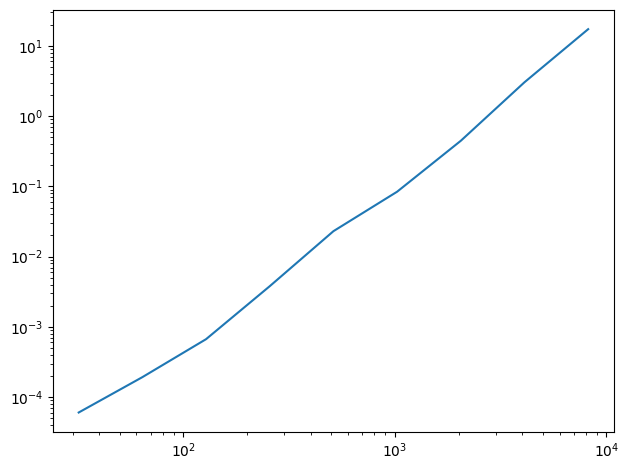

In [10]:
plot_bests(ns, bests1)

Наклон полученной прямой составил **2.29**. Это значение указывает на то, что временная асимптотическая сложность алгоритма действительно превышает $O(n^2)$. Однако на рассмотренных выборках данных сложность алгоритма оказывается ближе к $O(n^2)$, чем к $O(n^3)$, что может быть связано с особенностями конкретных данных или реализации алгоритма.


### 6.1.2. Функция `analyze2`

In [11]:
bests2 = run_speed_test(ns, analyze2)

32
30.5 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
64
106 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
128
390 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
256
1.92 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
512
5.82 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
45.3 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
149 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
4096
467 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
8192
1.95 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


np.float64(2.0310240905760435)

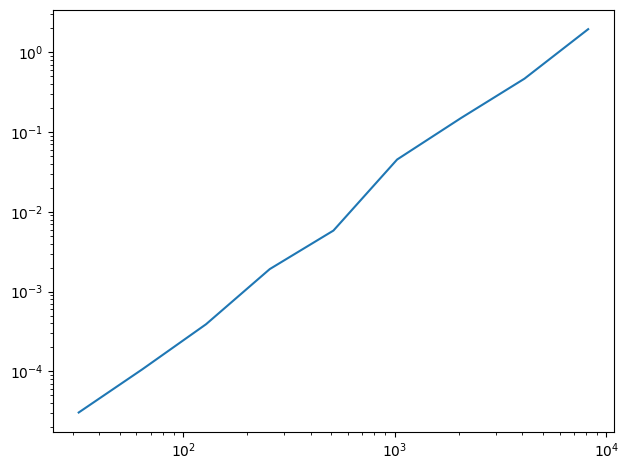

In [12]:
plot_bests(ns, bests2)

В данном случае получено значение наклона **2.03**, что близко к заявленной сложности алгоритма $O(n^2)$.


Поупражняемся также с функциями `dct_iv` и `scipy.fftpack.dct`.

Объявим функцию `dct_iv`.

In [13]:
def dct_iv(ys):
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

Добавим функции-обертки для `dct_iv` и `dct`, чтобы не писать новые тестирующие функции.

In [14]:
def dct_iv_wrapper(ys, fs, ts):
    return dct_iv(ys)

def dct_wrapper(ys, fs, ts):
    return dct(ys)

### 6.1.3. Функция `dct_iv`

In [15]:
bests3 = run_speed_test(ns, dct_iv_wrapper)

32
46.9 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
64
122 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
128
442 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
256
2.36 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
512
5.91 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
40.3 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
149 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
4096
456 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
8192
1.74 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


np.float64(1.9530818623996793)

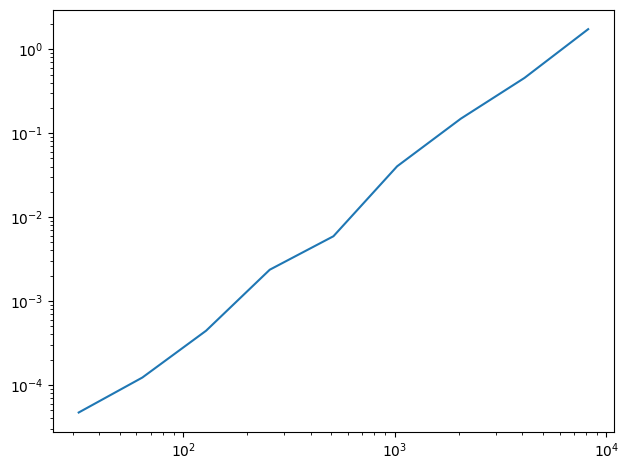

In [16]:
plot_bests(ns, bests3)

Получено, что временная сложность алгоритма **`dct_iv`** составляет $O(n^2)$.


### 6.1.4. Функция `scipy.fftpack.dct`

In [17]:
bests4 = run_speed_test(ns, dct_wrapper)

32
5.83 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
64
6.7 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
128
6.77 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
256
7.24 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
512
17.1 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
1024
25.3 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
2048
32 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
4096
43.9 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
8192
89.5 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)


np.float64(0.5031391219812288)

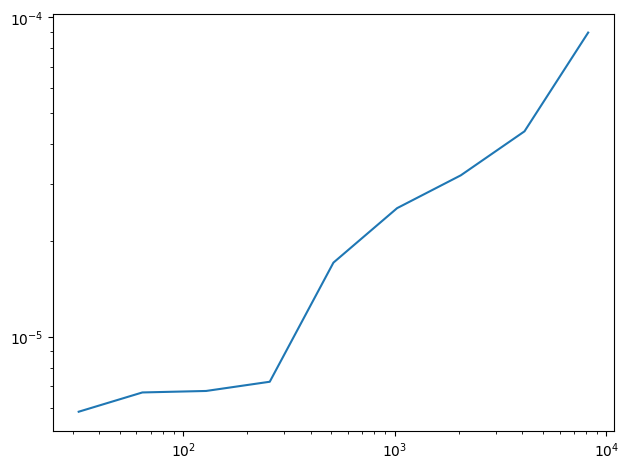

In [19]:
plot_bests(ns, bests4)

Сложность алгоритма **`scipy.fftpack.dct`** не выражается в виде $O(n^k)$, однако, вероятно, она меньше, чем у всех ранее рассмотренных функций.

Пункт 2

Реализуем алгоритм сжатия звука на основе дискретного косинусного преобразования (ДКП).  
Для этого будем обрабатывать небольшие сегменты записи, удаляя частотные компоненты, амплитуда которых слишком низка и которые почти не слышны.

Для примера воспользуемся записью скрипки, использованной ранее.

In [21]:
wave = read_wave('./violin.wav')
wave.make_audio()

Возьмем небольшой сегмент записи.

In [22]:
segment = wave.segment(start=1, duration=0.5)
segment.normalize()
segment.make_audio()

Получим ДКП сегмента:

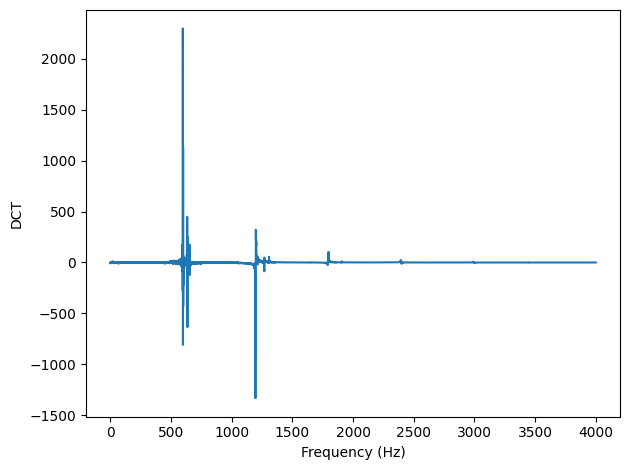

In [23]:
seg_dct = segment.make_dct()
seg_dct.plot(high=4000)
decorate(xlabel='Frequency (Hz)', ylabel='DCT')

Напишем функцию, которая принимает ДКП сигнала и зануляет все элементы, меньшие некоторого порогового значения.

In [24]:
def compress(dct: Dct, threshold: np.int64):
    cnt = 0
    for i, amp in enumerate(dct.amps):
        if np.abs(amp) < threshold:
            dct.hs[i] = 0
            cnt += 1
    n = len(dct.amps)
    print(f'{(cnt / n * 100):.2f}% of entries eliminated.')

Применим её на полученном ДКП.

96.09% of entries eliminated.


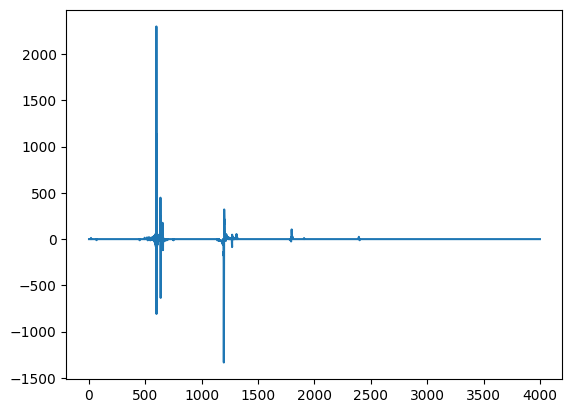

In [25]:
seg_dct = segment.make_dct()
compress(seg_dct, threshold=10)
seg_dct.plot(high=4000)

Прослушаем результат. Он звучит примерно так же, как исходный сегмент.

In [26]:
seg2 = seg_dct.make_wave()
seg2.make_audio()

Теперь попробуем удалить больше элементов.

In [27]:
dct = wave.segment(start=1, duration=0.5).make_dct()
compress(dct, threshold=400)
dct.make_wave().make_audio()

99.90% of entries eliminated.


С удалением почти всех частотных компонентов (в процентном соотношении) всё ещё можно различить скрип, однако качество звука заметно ухудшилось. Тем не менее, такая высокая степень сжатия может быть полезна в ситуациях, где экономия памяти критична, а сохранение качества записи менее важно.


Итак, наш алгоритм работает для отдельного сегмента. Чтобы применить его ко всему аудиофайлу, создадим ДКП-спектрограмму, аналогичную методу **`make_spectrogram`**.


In [28]:
def make_dct_spectrogram(wave, seg_length):
    window = np.hamming(seg_length)
    i, j = 0, seg_length
    step = seg_length // 2

    spec_map = {}

    while j < len(wave.ys):
        segment = wave.slice(i, j)
        segment.window(window)

        t = (segment.start + segment.end) / 2
        spec_map[t] = segment.make_dct()

        i += step
        j += step

    return Spectrogram(spec_map, seg_length)

Создадим ДКП-спектрограмму на основе объекта **`wave`** и применим функцию **`compress`** к каждому элементу спектрограммы для сжатия сигнала.


In [29]:
dcp_sp = make_dct_spectrogram(wave, 1024)
for _, dct in dcp_sp.spec_map.items():
    compress(dct, threshold=0.2)

100.00% of entries eliminated.
97.75% of entries eliminated.
95.12% of entries eliminated.
93.26% of entries eliminated.
91.89% of entries eliminated.
93.85% of entries eliminated.
93.16% of entries eliminated.
93.55% of entries eliminated.
93.55% of entries eliminated.
94.14% of entries eliminated.
91.80% of entries eliminated.
86.52% of entries eliminated.
86.23% of entries eliminated.
85.35% of entries eliminated.
82.62% of entries eliminated.
82.91% of entries eliminated.
80.27% of entries eliminated.
78.12% of entries eliminated.
78.32% of entries eliminated.
78.12% of entries eliminated.
77.44% of entries eliminated.
73.44% of entries eliminated.
78.03% of entries eliminated.
75.00% of entries eliminated.
79.30% of entries eliminated.
78.12% of entries eliminated.
78.03% of entries eliminated.
78.81% of entries eliminated.
74.90% of entries eliminated.
76.07% of entries eliminated.
73.73% of entries eliminated.
76.95% of entries eliminated.
74.32% of entries eliminated.
78.81% of

Преобразуем ДКП-спектрограмму обратно в объект **`Wave`**. В результате получим сжатый аудиофайл, который звучит почти так же, как оригинальный, но с дополнительными помехами.

In [30]:
dcp_sp.make_wave().make_audio()

Пункт 3

В блокноте **`phase.ipynb`** автор исследует влияние фазы на восприятие звука. Повторим аналогичные эксперименты, используя другой сегмент звука.

Объявим необходимые для работы функции.

In [31]:
def random_angle(spectrum):
    res = spectrum.copy()
    angles = np.random.uniform(0, PI2, len(spectrum))
    res.hs *= np.exp(1j * angles)
    return res

def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= np.exp(1j * offset)
    return res

def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res

def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = np.nan
    plt.plot(spectrum.fs, angles, 'x')
    decorate(xlabel='Frequency (Hz)',
             ylabel='Phase (radian)')

def plot_three(spectrum, thresh=1):
    """Plot amplitude, phase, and waveform.

    spectrum: Spectrum object
    thresh: threshold passed to plot_angle
    """
    plt.figure(figsize=(10, 4))
    plt.subplot(1,3,1)
    spectrum.plot()
    plt.subplot(1,3,2)
    plot_angle(spectrum, thresh=thresh)
    plt.subplot(1,3,3)
    wave = spectrum.make_wave()
    wave.unbias()
    wave.normalize()
    wave.segment(duration=0.01).plot()
    display(wave.make_audio())

Считаем аудиофайл.

In [32]:
wave = read_wave('./thisk.wav')
wave.make_audio()

Возьмем небольшой сегмент.

In [33]:
segment = wave.segment(start=4.1, duration=0.9)

Получим аудио, а также визуализируем амплитуды, углы и форму сигнала.

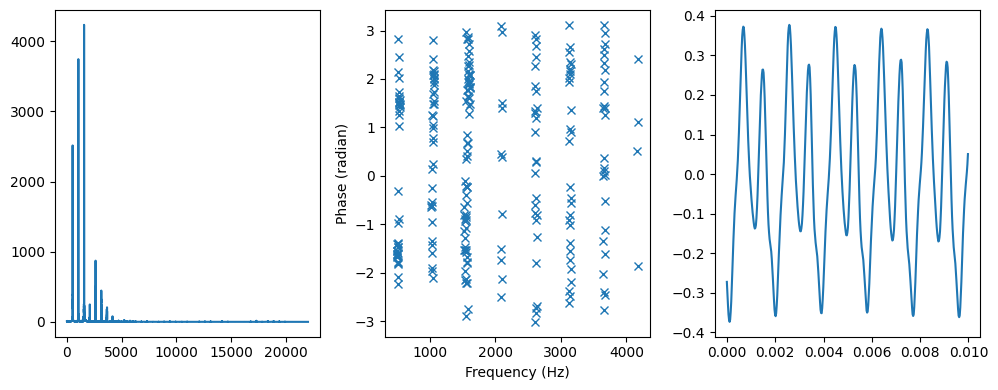

In [34]:
spectrum = segment.make_spectrum()
plot_three(spectrum, thresh=50)

Сделаем все углы равными нулю.

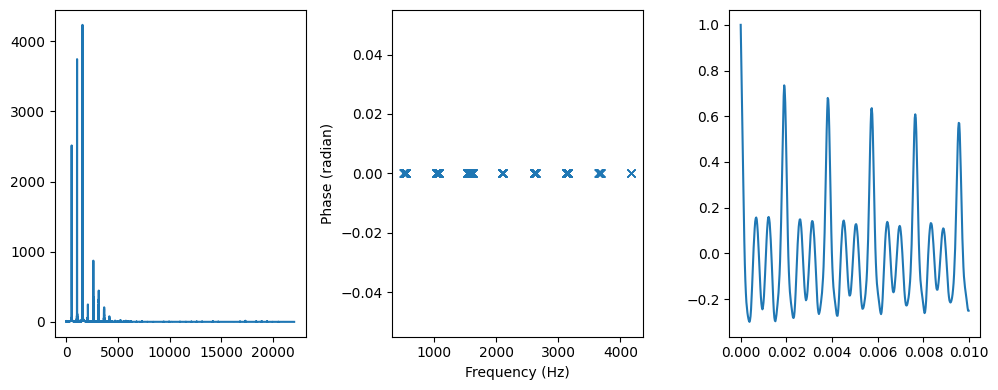

In [35]:
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

Заметим, что теперь сегмент звучит так, будто амплитуда периодически то возрастает, то уменьшается.

Повернем углы на 2 радиана.

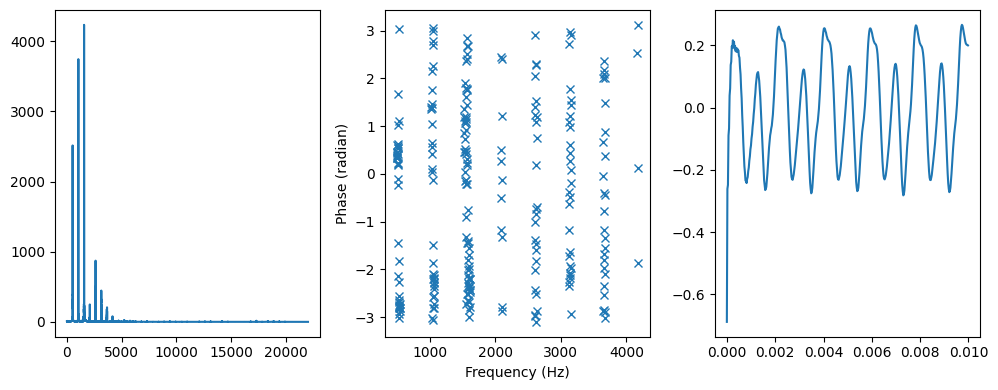

In [36]:
spectrum3 = rotate_angle(spectrum, 2)
plot_three(spectrum3, thresh=50)

Аудиофайл звучит примерно так же.

Рандомизируем углы.

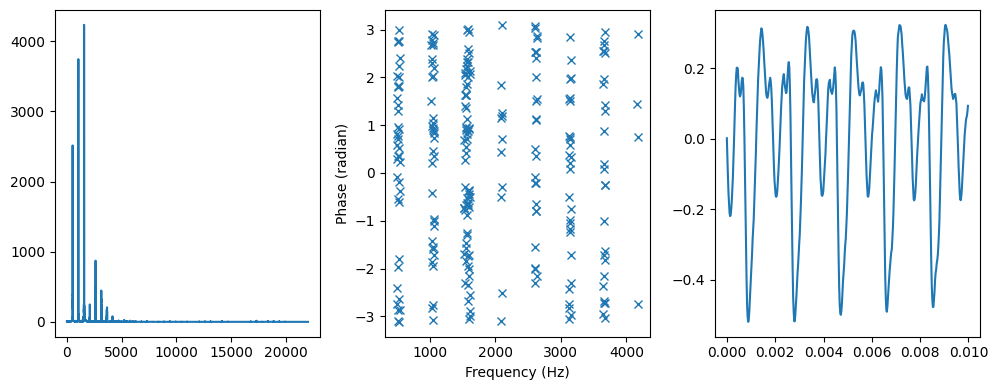

In [37]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

Полученный эффект на слух похож на тот, что происходит, когда мы зануляем углы.